<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICS40125 - Laboratorio N°07

**Objetivo**: Aplicar técnicas básicas de **Machine Learning** (tanto regresión como clasificación), desde la preparación de datos hasta el entrenamiento y evaluación de modelos.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.



## Regresión


<img src="https://cdn-icons-png.flaticon.com/512/2400/2400362.png" width = "300" align="center"/>


Los datos utilizados corresponden a propiedades localizadas en un distrito específico de California, junto con algunas estadísticas resumen extraídas del censo de 1990. Es importante tener en cuenta que los datos no han sido procesados previamente, por lo que será necesario realizar algunas etapas de limpieza y preprocesamiento.

Las columnas incluidas en el conjunto de datos son las siguientes (sus nombres son descriptivos):

* **longitude**: Longitud geográfica de la propiedad.
* **latitude**: Latitud geográfica de la propiedad.
* **housingmedianage**: Edad media de las viviendas en la zona.
* **total_rooms**: Número total de habitaciones.
* **total_bedrooms**: Número total de dormitorios.
* **population**: Población en el área circundante.
* **households**: Número de hogares en la zona.
* **median_income**: Ingreso medio por hogar.
* **medianhousevalue**: Valor medio de la propiedad.
* **ocean_proximity**: Proximidad al océano.

El objetivo de este análisis es predecir el valor medio de las propiedades utilizando las características proporcionadas.

Para completar este laboratorio, se recomienda seguir la siguiente rúbrica de trabajo:

1. **Definición del problema**: Clarificar el objetivo del análisis y los resultados esperados.
2. **Estadística descriptiva**: Resumir las principales características de los datos a través de medidas estadísticas.
3. **Visualización descriptiva**: Utilizar gráficos para explorar los datos y sus relaciones.
4. **Preprocesamiento**: Realizar los pasos necesarios de limpieza y transformación de los datos.
5. **Selección de modelo**: Comparar al menos cuatro modelos de predicción diferentes.
6. **Métricas y análisis de resultados**: Evaluar el rendimiento de los modelos utilizando métricas apropiadas.
7. **Visualización de resultados del modelo**: Crear gráficos que muestren el desempeño de los modelos.
8. **Conclusiones**: Resumir los hallazgos del análisis.

> **Nota**: Se anima a los estudiantes a desarrollar un análisis más profundo si lo desean. Pueden consultar como referencia el siguiente [enlace](https://www.kaggle.com/camnugent/california-housing-prices).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def regression_metrics(df):
    """
    Aplicar las distintas métricas definidas
    :param df: DataFrame con las columnas: ['y', 'yhat']
    :return: DataFrame con las métricas especificadas
    """
    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mean_absolute_error(y_true, y_pred), 4)]
    df_result['mse'] = [round(mean_squared_error(y_true, y_pred), 4)]
    df_result['rmse'] = [round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)]
    df_result['mape'] = [round(mean_absolute_percentage_error(y_true, y_pred), 4)]
    df_result['smape'] = [round(2 * mean_absolute_percentage_error(y_true, y_pred) / (mean_absolute_percentage_error(y_true, y_pred) + 100), 4)]

    return df_result

In [3]:
from sklearn.datasets import fetch_california_housing

# Cargar los datos de housing
housing_data = fetch_california_housing(as_frame=True)

# Convertir los datos en un DataFrame de pandas
housing = housing_data['data']
housing['target'] = housing_data['target']

# Visualizar las primeras filas del DataFrame
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Dimensiones del dataset: (20640, 9)

Primeras filas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


None


Valores nulos por columna:


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
target,0



Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
target,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


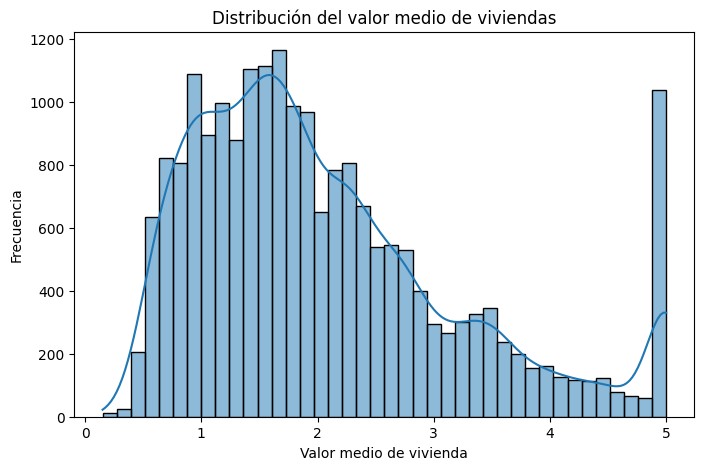

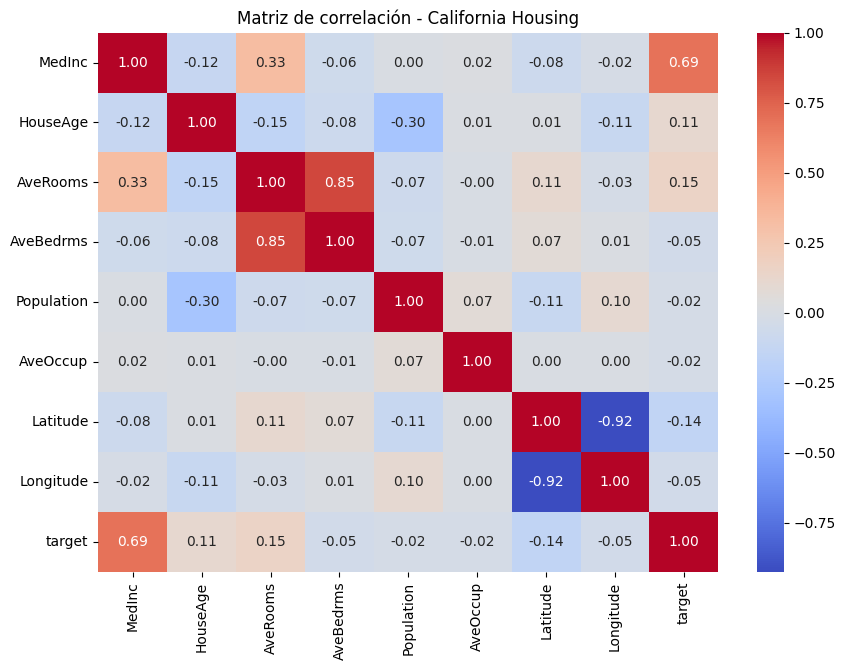

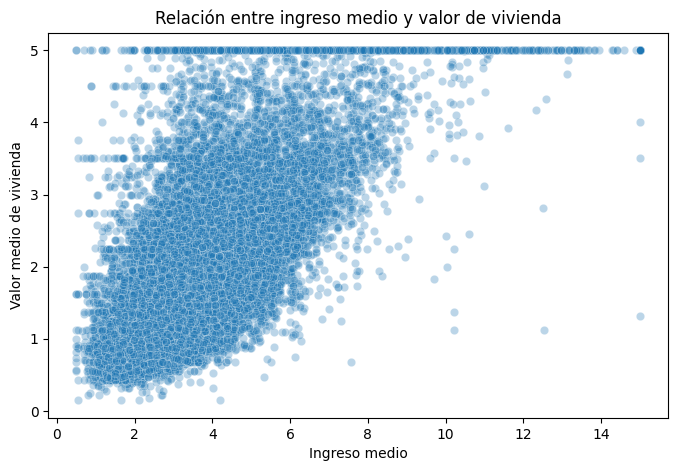

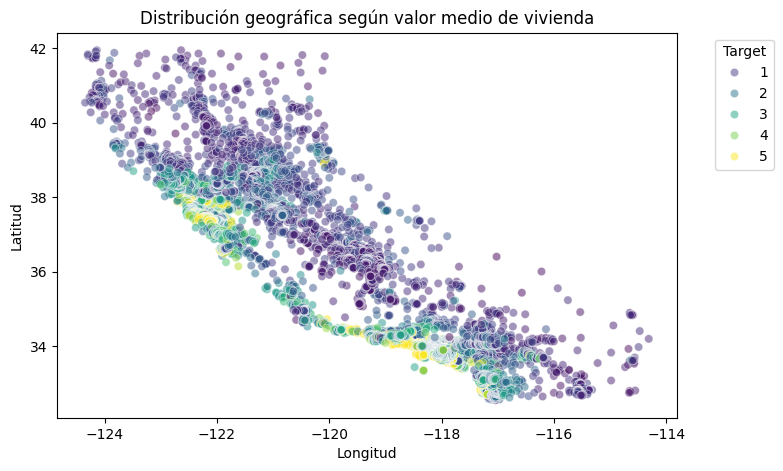

Tamaño entrenamiento: (16512, 8)
Tamaño test: (4128, 8)


,modelo,mae,mse,rmse,mape,smape,r2
3,Random Forest,0.3276,0.2551,0.5051,18.9207,0.3182,0.8053
4,Gradient Boosting,0.3716,0.2940,0.5422,21.5254,0.3543,0.7756
2,Lasso,0.5331,0.5545,0.7446,31.9349,0.4841,0.5769
1,Ridge,0.5332,0.5559,0.7456,31.9512,0.4843,0.5758
0,Linear Regression,0.5332,0.5559,0.7456,31.9522,0.4843,0.5758


Mejor modelo de regresión según RMSE: Random Forest


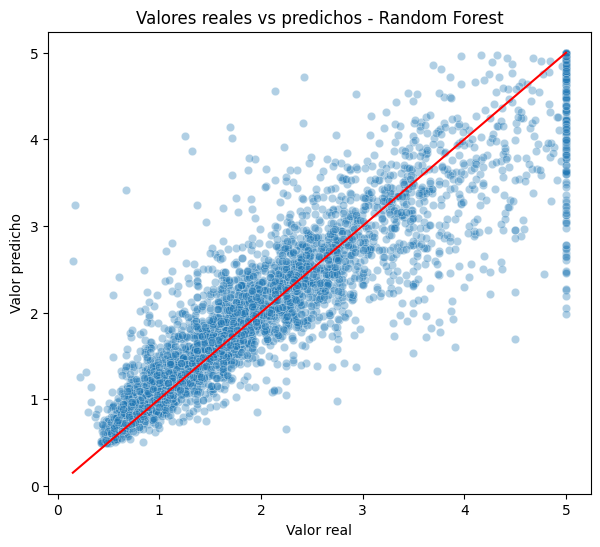

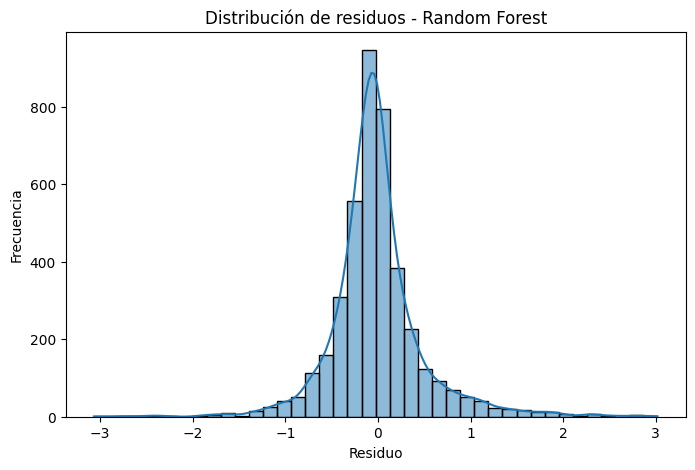

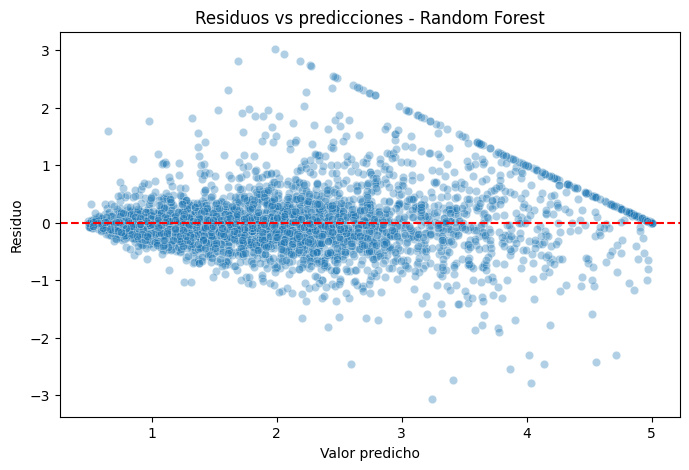

In [4]:
# Regresión: California Housing

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score

# 1. Definición del problema
# Objetivo: predecir el valor medio de viviendas usando variables socioeconómicas y geográficas.

print("Dimensiones del dataset:", housing.shape)
print("\nPrimeras filas:")
display(housing.head())

print("\nInformación general:")
display(housing.info())

print("\nValores nulos por columna:")
display(housing.isnull().sum())

print("\nEstadísticas descriptivas:")
display(housing.describe().T)

# 2. Visualización descriptiva

plt.figure(figsize=(8, 5))
sns.histplot(housing["target"], kde=True, bins=40)
plt.title("Distribución del valor medio de viviendas")
plt.xlabel("Valor medio de vivienda")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(housing.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación - California Housing")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=housing, x="MedInc", y="target", alpha=0.3)
plt.title("Relación entre ingreso medio y valor de vivienda")
plt.xlabel("Ingreso medio")
plt.ylabel("Valor medio de vivienda")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=housing, x="Longitude", y="Latitude", hue="target", palette="viridis", alpha=0.5)
plt.title("Distribución geográfica según valor medio de vivienda")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend(title="Target", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# 3. Preprocesamiento y train-test

X_reg = housing.drop(columns="target")
y_reg = housing["target"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Tamaño entrenamiento:", X_train_reg.shape)
print("Tamaño test:", X_test_reg.shape)

# 4. Comparar al menos cuatro modelos de regresión

regression_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001, max_iter=10000))
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=120,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

reg_results = []
reg_predictions = {}

for name, model in regression_models.items():
    model.fit(X_train_reg, y_train_reg)
    y_pred = model.predict(X_test_reg)

    temp_df = pd.DataFrame({
        "y": y_test_reg,
        "yhat": y_pred
    })

    metrics = regression_metrics(temp_df)
    metrics["r2"] = round(r2_score(y_test_reg, y_pred), 4)
    metrics["modelo"] = name

    reg_results.append(metrics)
    reg_predictions[name] = y_pred

reg_results_df = pd.concat(reg_results, ignore_index=True)
reg_results_df = reg_results_df[["modelo", "mae", "mse", "rmse", "mape", "smape", "r2"]]
display(reg_results_df.sort_values("rmse"))

# 5. Visualización de resultados

best_reg_model_name = reg_results_df.sort_values("rmse").iloc[0]["modelo"]
best_reg_pred = reg_predictions[best_reg_model_name]

print("Mejor modelo de regresión según RMSE:", best_reg_model_name)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test_reg, y=best_reg_pred, alpha=0.35)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], color="red")
plt.title(f"Valores reales vs predichos - {best_reg_model_name}")
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.show()

residuals = y_test_reg - best_reg_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=40)
plt.title(f"Distribución de residuos - {best_reg_model_name}")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=best_reg_pred, y=residuals, alpha=0.35)
plt.axhline(0, color="red", linestyle="--")
plt.title(f"Residuos vs predicciones - {best_reg_model_name}")
plt.xlabel("Valor predicho")
plt.ylabel("Residuo")
plt.show()

El dataset de California Housing contiene **20.640 observaciones** y **9 variables**, incluyendo la variable objetivo `target`, que representa el valor medio de las viviendas. No se observan valores nulos en las columnas, por lo que la base puede utilizarse directamente para entrenar modelos de regresión.

En el análisis descriptivo se observa que la variable `MedInc`, correspondiente al ingreso medio, tiene una relación importante con el valor de la vivienda. Esto se confirma visualmente en el gráfico de dispersión, donde los hogares ubicados en zonas de mayor ingreso tienden a presentar valores de vivienda más altos. Además, las variables geográficas `Latitude` y `Longitude` permiten observar diferencias espaciales en los precios, lo que sugiere que la ubicación también influye en el valor de las viviendas.

Se compararon cinco modelos de regresión: Linear Regression, Ridge, Lasso, Random Forest y Gradient Boosting. El mejor desempeño lo obtuvo **Random Forest**, con un **RMSE de 0,5051**, un **MAE de 0,3276** y un **R² de 0,8053**. Esto significa que el modelo explica aproximadamente el **80,5% de la variabilidad** del valor medio de las viviendas en el conjunto de prueba.

Los modelos lineales, como Linear Regression, Ridge y Lasso, presentaron un desempeño menor, con R² cercano a **0,576**. Esto indica que la relación entre las variables explicativas y el valor de la vivienda no es completamente lineal. En cambio, Random Forest logra capturar relaciones más complejas entre ingreso, ubicación, antigüedad de la vivienda, ocupación y características del hogar.

En conclusión, para este problema de regresión, **Random Forest es el modelo más adecuado**, ya que entrega menor error de predicción y mayor capacidad explicativa que los modelos lineales. Esto muestra que, cuando existen relaciones no lineales o interacciones entre variables, los modelos basados en árboles pueden superar a los modelos lineales tradicionales.

## Clasificación


<img src="https://miro.medium.com/v2/resize:fit:372/0*EwdH1C6ThmpwY0Qo.png" width = "400" align="center"/>

El objetivo de este proyecto es realizar la mejor predicción posible de las imágenes a partir de los datos disponibles. Para lograrlo, es necesario seguir los pasos habituales en un proyecto de _Machine Learning_, que incluyen la exploración estadística, la visualización y el preprocesamiento de los datos.

Se solicita lo siguiente:

* Ajustar al menos tres modelos de clasificación:
    * Regresión logística.
    * K-Nearest Neighbors.
    * Un algoritmo adicional o más, de libre elección. Puedes consultar [esta lista de algoritmos](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning) para obtener ideas.
  
* Realizar predicciones con cada uno de los tres modelos utilizando el conjunto de datos de _test_ y calcular sus respectivas puntuaciones (_score_).

* Evaluar y analizar los resultados de los modelos utilizando las siguientes métricas de rendimiento:
    * **Accuracy**
    * **Precision**
    * **Recall**
    * **F1-score**

### Exploración de los datos
A continuación se carga el conjunto de datos a utilizar, a través del sub-módulo `datasets` de `sklearn`.

In [5]:
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt

%matplotlib inline

In [6]:
digits_dict = datasets.load_digits()
print(digits_dict["DESCR"])

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [7]:
# informacion de las columnas
digits_dict.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [8]:
# informacion del target
digits_dict["target"]

array([0, 1, 2, ..., 8, 9, 8])

A continuación se crea dataframe declarado como `digits` con los datos de `digits_dict` tal que tenga 65 columnas, las 6 primeras a la representación de la imagen en escala de grises (0-blanco, 255-negro) y la última correspondiente al dígito (`target`) con el nombre _target_.

In [9]:
# leer datos
digits = (
    pd.DataFrame(
        digits_dict["data"],
    )
    .rename(columns=lambda x: f"c{x:02d}")
    .assign(target=digits_dict["target"])
    .astype(int)
)

digits.head()

,c00,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,target
0,0,0,5,13,9,1,0,0,0,0,...,0,0,0,6,13,10,0,0,0,0
1,0,0,0,12,13,5,0,0,0,0,...,0,0,0,0,11,16,10,0,0,1
2,0,0,0,4,15,12,0,0,0,0,...,0,0,0,0,3,11,16,9,0,2
3,0,0,7,15,13,1,0,0,0,8,...,0,0,0,7,13,13,9,0,0,3
4,0,0,0,1,11,0,0,0,0,0,...,0,0,0,0,2,16,4,0,0,4


### Ejercicio 1
**Análisis exploratorio:** Realiza tu análisis exploratorio, no debes olvidar nada! Recuerda, cada análisis debe responder una pregunta.

Algunas sugerencias:

* ¿Cómo se distribuyen los datos?
* ¿Cuánta memoria estoy utilizando?
* ¿Qué tipo de datos son?
* ¿Cuántos registros por clase hay?
* ¿Hay registros que no se correspondan con tu conocimiento previo de los datos?

Dimensiones del DataFrame digits:
(1797, 65)

Primeras filas:


,c00,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,target
0,0,0,5,13,9,1,0,0,0,0,...,0,0,0,6,13,10,0,0,0,0
1,0,0,0,12,13,5,0,0,0,0,...,0,0,0,0,11,16,10,0,0,1
2,0,0,0,4,15,12,0,0,0,0,...,0,0,0,0,3,11,16,9,0,2
3,0,0,7,15,13,1,0,0,0,8,...,0,0,0,7,13,13,9,0,0,3
4,0,0,0,1,11,0,0,0,0,0,...,0,0,0,0,2,16,4,0,0,4



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   c00     1797 non-null   int64
 1   c01     1797 non-null   int64
 2   c02     1797 non-null   int64
 3   c03     1797 non-null   int64
 4   c04     1797 non-null   int64
 5   c05     1797 non-null   int64
 6   c06     1797 non-null   int64
 7   c07     1797 non-null   int64
 8   c08     1797 non-null   int64
 9   c09     1797 non-null   int64
 10  c10     1797 non-null   int64
 11  c11     1797 non-null   int64
 12  c12     1797 non-null   int64
 13  c13     1797 non-null   int64
 14  c14     1797 non-null   int64
 15  c15     1797 non-null   int64
 16  c16     1797 non-null   int64
 17  c17     1797 non-null   int64
 18  c18     1797 non-null   int64
 19  c19     1797 non-null   int64
 20  c20     1797 non-null   int64
 21  c21     1797 non-null   int64
 22  c22     1797 non-null   in

,count
int64,65



Uso de memoria:
934572 bytes

Valores nulos por columna:


np.int64(0)


Filas duplicadas:
0

Distribución de clases:


,count
target,
0,178
1,182
2,177
3,183
4,181
5,182
6,181
7,179
8,174


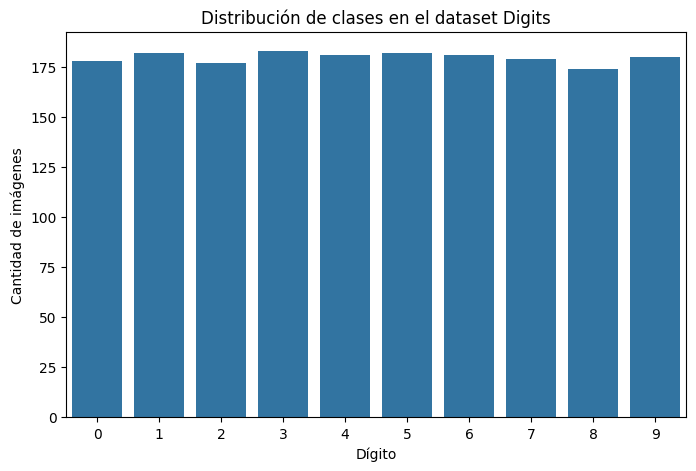


Resumen estadístico de los pixeles:


,count,mean,std,min,25%,50%,75%,max
c00,1797.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
c01,1797.0,0.303840,0.907192,0.0,0.0,0.0,0.0,8.0
c02,1797.0,5.204786,4.754826,0.0,1.0,4.0,9.0,16.0
c03,1797.0,11.835838,4.248842,0.0,10.0,13.0,15.0,16.0
c04,1797.0,11.848080,4.287388,0.0,10.0,13.0,15.0,16.0
c05,1797.0,5.781859,5.666418,0.0,0.0,4.0,11.0,16.0
c06,1797.0,1.362270,3.325775,0.0,0.0,0.0,0.0,16.0
c07,1797.0,0.129661,1.037383,0.0,0.0,0.0,0.0,15.0
c08,1797.0,0.005565,0.094222,0.0,0.0,0.0,0.0,2.0
c09,1797.0,1.993879,3.196160,0.0,0.0,0.0,3.0,16.0



Valor mínimo de los pixeles: 0
Valor máximo de los pixeles: 16


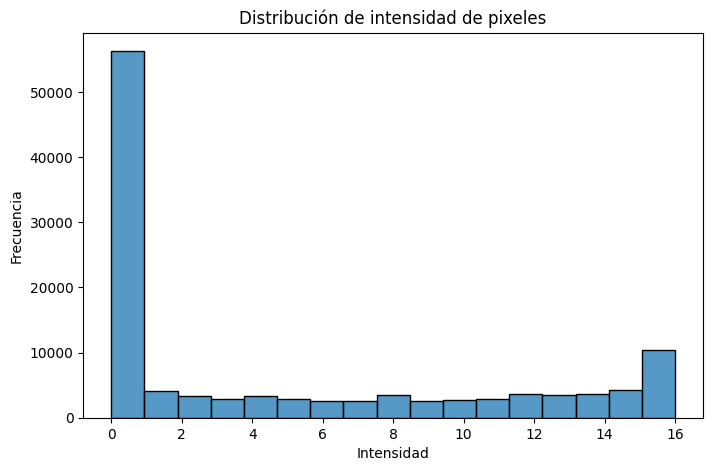

In [10]:
# Ejercicio 1: Análisis exploratorio del dataset Digits

print("Dimensiones del DataFrame digits:")
print(digits.shape)

print("\nPrimeras filas:")
display(digits.head())

print("\nInformación general:")
digits.info()

print("\nTipos de datos:")
display(digits.dtypes.value_counts())

print("\nUso de memoria:")
print(digits.memory_usage(deep=True).sum(), "bytes")

print("\nValores nulos por columna:")
display(digits.isnull().sum().sum())

print("\nFilas duplicadas:")
print(digits.duplicated().sum())

print("\nDistribución de clases:")
class_counts = digits["target"].value_counts().sort_index()
display(class_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Distribución de clases en el dataset Digits")
plt.xlabel("Dígito")
plt.ylabel("Cantidad de imágenes")
plt.show()

print("\nResumen estadístico de los pixeles:")
display(digits.drop(columns="target").describe().T.head(10))

# Revisar rango de valores de pixeles
pixel_values = digits.drop(columns="target").values

print("\nValor mínimo de los pixeles:", pixel_values.min())
print("Valor máximo de los pixeles:", pixel_values.max())

plt.figure(figsize=(8, 5))
sns.histplot(pixel_values.flatten(), bins=17)
plt.title("Distribución de intensidad de pixeles")
plt.xlabel("Intensidad")
plt.ylabel("Frecuencia")
plt.show()

El dataset Digits contiene **1.797 observaciones** y **65 columnas**. De estas, 64 corresponden a pixeles de imágenes de 8x8 y una corresponde a la variable objetivo `target`, que indica el dígito representado en cada imagen.

Todas las columnas son de tipo entero y no existen valores nulos ni filas duplicadas. Esto indica que la base está limpia y lista para ser utilizada en modelos de clasificación. Además, el rango de intensidad de los pixeles va desde **0 hasta 16**, lo que representa distintos niveles de intensidad en cada imagen.

La distribución de clases está bastante balanceada. Cada dígito tiene una cantidad de observaciones similar, entre aproximadamente **174 y 183 imágenes** por clase. Esto es positivo para el entrenamiento de modelos de clasificación, ya que evita que el modelo aprenda de forma sesgada hacia una clase dominante.

El análisis de los pixeles muestra que algunas columnas tienen media igual o muy cercana a cero, lo que indica que ciertos pixeles suelen estar apagados o sin información en gran parte de las imágenes. En cambio, otros pixeles presentan valores promedio más altos, reflejando las zonas donde normalmente se dibujan los trazos de los números.

En conclusión, el dataset presenta buena calidad, clases balanceadas y una estructura adecuada para entrenar modelos de clasificación de dígitos escritos a mano.

### Ejercicio 2
**Visualización:** Para visualizar los datos utilizaremos el método `imshow` de `matplotlib`. Resulta necesario convertir el arreglo desde las dimensiones (1,64)  a (8,8) para que la imagen sea cuadrada y pueda distinguirse el dígito. Superpondremos además el label correspondiente al dígito, mediante el método `text`. Esto nos permitirá comparar la imagen generada con la etiqueta asociada a los valores. Realizaremos lo anterior para los primeros 25 datos del archivo.

In [11]:
digits_dict["images"][0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

Visualiza imágenes de los dígitos utilizando la llave `images` de `digits_dict`.

> **Sugerencia**: Utiliza `plt.subplots` y el método `imshow`. Puedes hacer una grilla de varias imágenes al mismo tiempo!

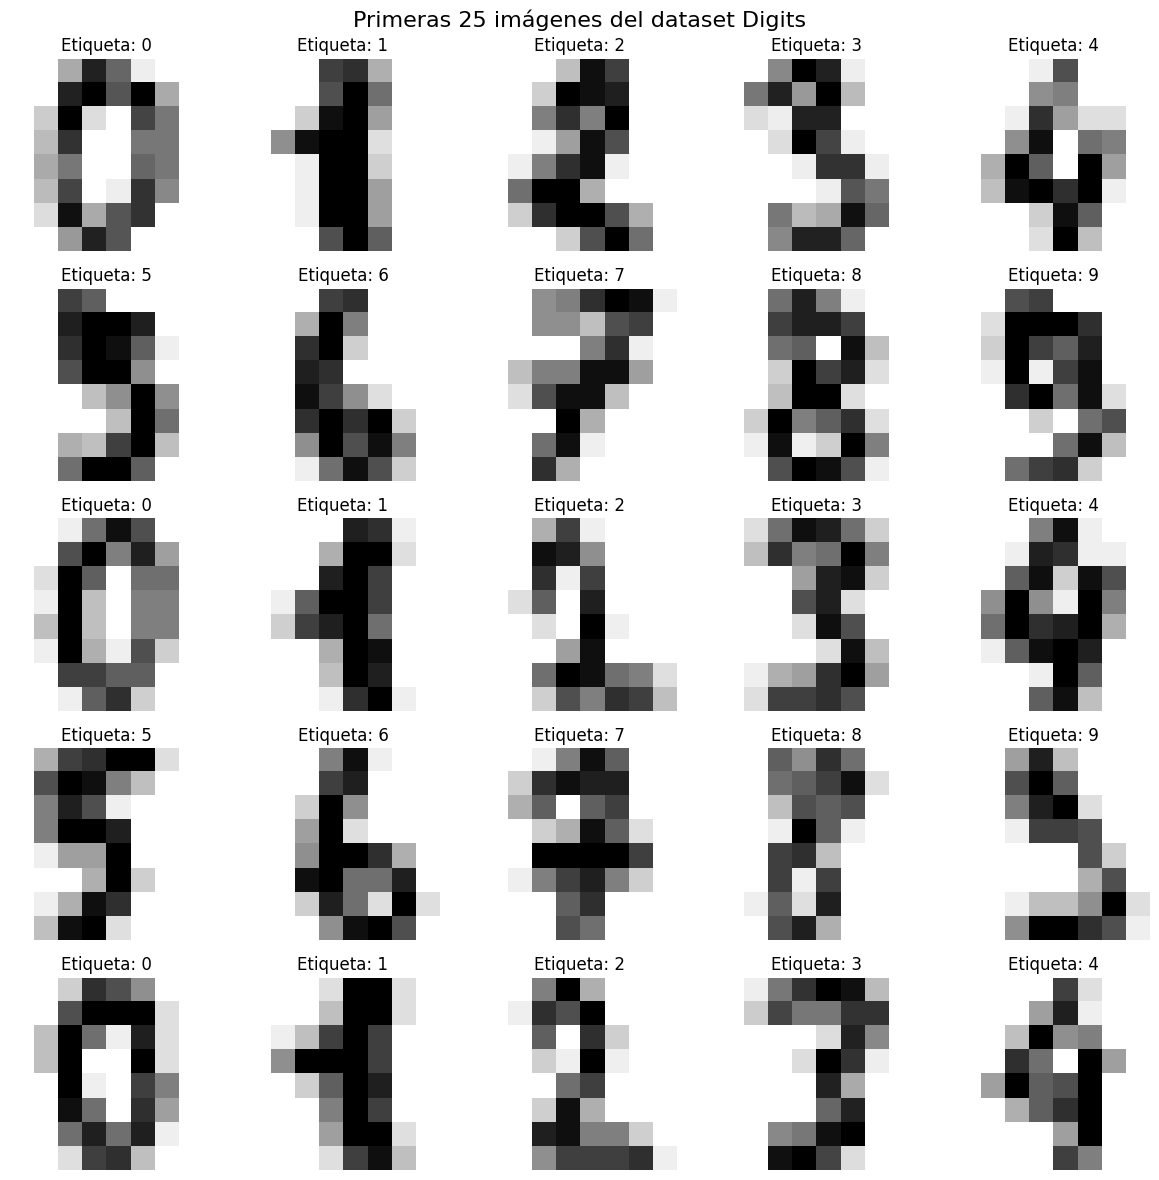

In [12]:
nx, ny = 5, 5
fig, axs = plt.subplots(nx, ny, figsize=(12, 12))

for i, ax in enumerate(axs.ravel()):
    ax.imshow(digits_dict["images"][i], cmap="gray_r", interpolation="nearest")
    ax.set_title(f"Etiqueta: {digits_dict['target'][i]}")
    ax.axis("off")

plt.suptitle("Primeras 25 imágenes del dataset Digits", fontsize=16)
plt.tight_layout()
plt.show()

La visualización de las primeras 25 imágenes permite observar directamente cómo están representados los dígitos dentro del dataset. Cada imagen corresponde a una matriz de **8x8 pixeles**, donde los valores más altos indican mayor intensidad del trazo.

A partir de las imágenes se puede ver que, aunque los dígitos son de baja resolución, los patrones generales son reconocibles. Esto permite que los modelos de clasificación puedan aprender diferencias visuales entre números como 0, 1, 2, 3 y así sucesivamente.

También se observa que algunos dígitos pueden tener formas similares o trazos menos claros, lo que puede generar errores de clasificación. Por ejemplo, ciertos casos de 8 y 9, o de 1 y 7, pueden ser más difíciles de distinguir dependiendo de la forma del trazo.

Esta visualización es importante porque permite comprender que el problema no es simplemente numérico, sino también visual: cada fila del dataset representa una imagen transformada en valores de pixeles.

### Ejercicio 3

**Machine Learning**: En esta parte usted debe entrenar los distintos modelos escogidos desde la librería de `skelearn`. Para cada modelo, debe realizar los siguientes pasos:

* **train-test**
     * Crear conjunto de entrenamiento y testeo (usted determine las proporciones adecuadas).
     * Imprimir por pantalla el largo del conjunto de entrenamiento y de testeo.
  
* **modelo**:
     * Instanciar el modelo objetivo desde la librería sklearn.

* **Métricas**:
     * Graficar matriz de confusión.
     * Analizar métricas de error.



__Preguntas a responder:__

* ¿Cuál modelo es mejor basado en sus métricas?
* ¿Cuál modelo demora menos tiempo en ajustarse?
* ¿Qué modelo escoges?


Largo conjunto de entrenamiento: 1437
Largo conjunto de test: 360


,modelo,accuracy,precision_macro,recall_macro,f1_macro,tiempo_ajuste_seg
3,SVM RBF,0.975000,0.975960,0.974762,0.974847,1.572493
0,Logistic Regression,0.972222,0.972126,0.971905,0.971940,0.912062
1,KNN,0.963889,0.964590,0.963722,0.963440,0.012612
2,Random Forest,0.963889,0.964407,0.963488,0.963391,1.671078



Modelo: Logistic Regression

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.89      0.89      0.89        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



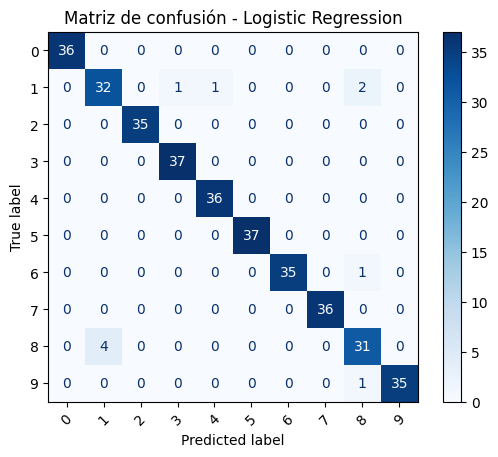


Modelo: KNN

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       0.95      1.00      0.97        35
           3       1.00      0.97      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      0.97      0.97        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        36
           8       0.97      0.89      0.93        35
           9       0.97      0.89      0.93        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



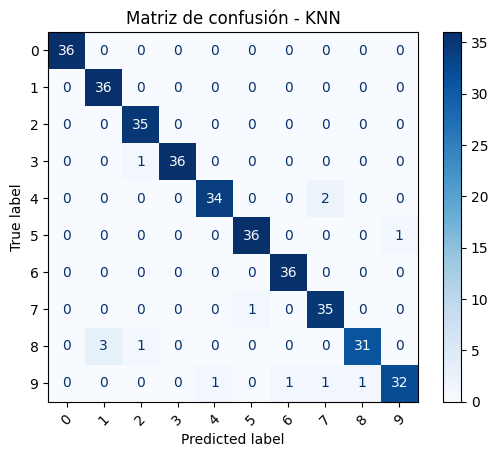


Modelo: Random Forest

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.92      0.97      0.95        36
           2       1.00      0.97      0.99        35
           3       0.97      0.97      0.97        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.92      1.00      0.96        36
           8       0.94      0.86      0.90        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



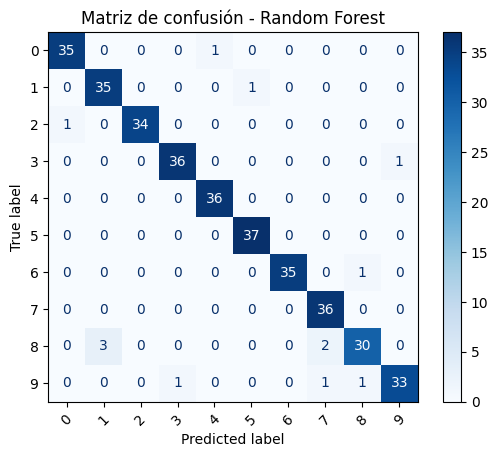


Modelo: SVM RBF

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      0.97      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       0.97      1.00      0.99        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        36
           8       1.00      0.91      0.96        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360



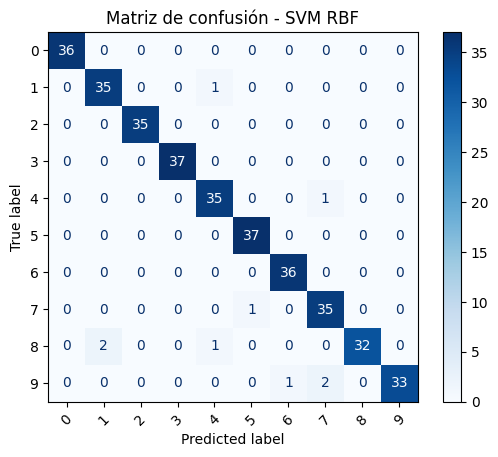

Mejor modelo según F1 macro: SVM RBF


In [14]:
# features, target

X = digits.drop(columns="target").values
y = digits["target"].values
# Ejercicio 3: Entrenamiento y evaluación de modelos de clasificación

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import time

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Largo conjunto de entrenamiento:", len(X_train))
print("Largo conjunto de test:", len(X_test))

# Modelos a comparar
classification_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=42))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "SVM RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=42))
    ])
}

classification_results = []
trained_models = {}

for name, model in classification_models.items():
    start_time = time.time()

    model.fit(X_train, y_train)

    fit_time = time.time() - start_time

    y_pred = model.predict(X_test)

    classification_results.append({
        "modelo": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro"),
        "recall_macro": recall_score(y_test, y_pred, average="macro"),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "tiempo_ajuste_seg": fit_time
    })

    trained_models[name] = model

classification_results_df = pd.DataFrame(classification_results).sort_values(
    "f1_macro", ascending=False
)

display(classification_results_df)

# Reportes y matrices de confusión
for name, model in trained_models.items():
    print("\n" + "=" * 80)
    print(f"Modelo: {name}")

    y_pred = model.predict(X_test)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Matriz de confusión - {name}")
    plt.show()

# Seleccionar mejor modelo según F1 macro
best_model_name = classification_results_df.iloc[0]["modelo"]
best_model = trained_models[best_model_name]

print("Mejor modelo según F1 macro:", best_model_name)

Se compararon cuatro modelos de clasificación para predecir dígitos escritos a mano: Logistic Regression, KNN, Random Forest y SVM con kernel RBF. El conjunto de datos fue dividido en **1.437 observaciones de entrenamiento** y **360 observaciones de prueba**.

El mejor modelo según F1 macro fue **SVM RBF**, con un **accuracy de 0,9750**, una **precision macro de 0,9760**, un **recall macro de 0,9748** y un **F1 macro de 0,9748**. Esto significa que el modelo clasifica correctamente cerca del **97,5%** de las imágenes del conjunto de prueba.

Logistic Regression también obtuvo un desempeño muy alto, con accuracy de **0,9722** y F1 macro de **0,9719**. KNN y Random Forest tuvieron resultados levemente inferiores, ambos con accuracy de **0,9639**. Aunque todos los modelos funcionan bien, SVM RBF logra el mejor equilibrio entre precisión y capacidad de identificar correctamente las clases.

Al revisar los reportes de clasificación, se observa que la mayoría de los dígitos alcanza valores de precision, recall y F1-score cercanos a 1. Sin embargo, algunos dígitos presentan mayores dificultades. Por ejemplo, en varios modelos los dígitos **1, 8 y 9** tienen métricas algo más bajas que otras clases, lo que puede deberse a similitudes visuales entre algunos trazos.

En conclusión, **SVM RBF es el mejor modelo de clasificación en este laboratorio**, ya que obtiene el mayor F1 macro y muestra un desempeño consistente entre las distintas clases.

Las matrices de confusión muestran que los modelos clasifican correctamente la gran mayoría de los dígitos, ya que la mayor concentración de valores se encuentra en la diagonal principal. Esto significa que las predicciones coinciden con las etiquetas reales en la mayoría de los casos.

En el caso de **SVM RBF**, la matriz de confusión confirma su alto desempeño, ya que presenta muy pocos errores de clasificación. La mayoría de los dígitos son identificados correctamente, especialmente clases como 0, 2, 3, 5 y 6, que muestran resultados muy altos.

Los errores se concentran principalmente en algunos dígitos que visualmente pueden ser más parecidos, como 8 y 9, o 1 y 7. Esto es esperable en problemas de reconocimiento de imágenes, ya que ciertos trazos manuscritos pueden generar confusión incluso para una persona.

En general, las matrices de confusión respaldan las métricas obtenidas: todos los modelos tienen buen rendimiento, pero **SVM RBF es el que presenta el mejor balance general**.

### Ejercicio 4

__Comprensión del modelo:__ Tomando en cuenta el **mejor modelo entontrado** en el `Ejercicio 3`, debe comprender e interpretar minuciosamente los resultados y gráficos asocados al modelo en estudio, para ello debe resolver los siguientes puntos:


 * **Curva AUC–ROC**: Replica el ejemplo del siguiente  [link](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html#sphx-glr-auto-examples-model-selection-plot-roc-py) pero con el modelo, parámetros y métrica adecuada. Saque conclusiones del gráfico.

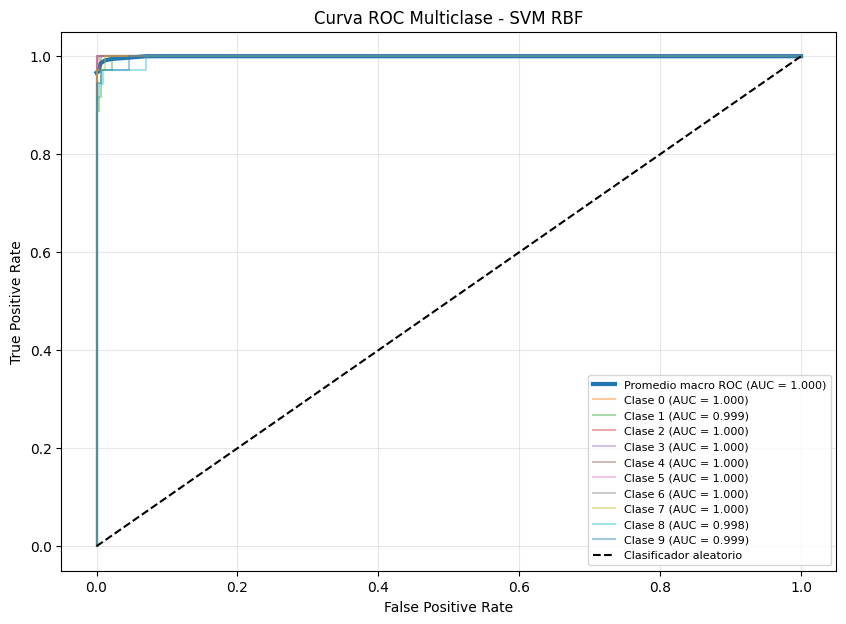

,clase,auc
0,0,1.000000
1,1,0.998971
2,2,1.000000
3,3,1.000000
4,4,0.999829
5,5,1.000000
6,6,0.999914
7,7,0.999657
8,8,0.997626
9,9,0.998543


AUC macro: 0.9996


In [15]:
# Ejercicio 4: Curva AUC-ROC multiclass para el mejor modelo encontrado

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

# Binarizar etiquetas para evaluación ROC multiclass
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

# Obtener probabilidades del mejor modelo
# Si el modelo tiene predict_proba, se usa directamente.
# En caso contrario, se utiliza decision_function.
if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test)
else:
    y_score = best_model.decision_function(X_test)

# Calcular ROC y AUC por clase
fpr = {}
tpr = {}
roc_auc = {}

for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Promedio macro
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(len(classes)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= len(classes)

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(10, 7))

plt.plot(
    fpr["macro"],
    tpr["macro"],
    label=f"Promedio macro ROC (AUC = {roc_auc['macro']:.3f})",
    linewidth=3
)

for i, cls in enumerate(classes):
    plt.plot(
        fpr[i],
        tpr[i],
        alpha=0.4,
        label=f"Clase {cls} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Curva ROC Multiclase - {best_model_name}")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.show()

roc_auc_df = pd.DataFrame({
    "clase": classes,
    "auc": [roc_auc[i] for i in range(len(classes))]
})

display(roc_auc_df)
print("AUC macro:", round(roc_auc["macro"], 4))

La curva AUC-ROC se utilizó para evaluar la capacidad del mejor modelo, **SVM RBF**, para distinguir entre las distintas clases de dígitos. Los resultados muestran un desempeño excelente, con un **AUC macro de 0,9996**.

Los valores AUC por clase son todos muy cercanos a 1. Algunas clases, como **0, 2, 3 y 5**, alcanzan un AUC de **1,0000**, lo que indica una capacidad prácticamente perfecta para distinguir esos dígitos del resto. Otras clases, como 1, 4, 6, 7, 8 y 9, también presentan AUC muy altos, todos superiores a **0,997**.

Este resultado confirma que el modelo no solo tiene alto accuracy, sino que también separa muy bien las clases. En términos simples, el modelo logra asignar probabilidades o puntajes muy adecuados para diferenciar un dígito de los demás.

En conclusión, la curva ROC multiclase refuerza que **SVM RBF es un modelo altamente efectivo para clasificar los dígitos del dataset**.

### Ejercicio 5


__Visualizando Resultados:__ A continuación se provee código para comparar las etiquetas predichas vs las etiquetas reales del conjunto de _test_.

In [16]:
def mostrar_resultados(digits, model, nx=5, ny=5, label="correctos"):
    """
    Muestra los resultados de las predicciones de un modelo de clasificación en particular.
    Se toman aleatoriamente los valores de los resultados.

    - label == 'correctos': muestra los valores en los que el modelo acierta.
    - label == 'incorrectos': muestra los valores en los que el modelo no acierta.

    Observación: El modelo que se recibe como argumento no debe estar entrenado.

    :param digits: dataset 'digits'
    :param model: modelo de sklearn
    :param nx: número de filas (subplots)
    :param ny: número de columnas (subplots)
    :param label: 'correctos' o 'incorrectos'
    :return: gráficos matplotlib
    """

    X = digits.drop(columns="target").values
    y = digits["target"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)  # Ajustar el modelo
    y_pred = model.predict(X_test)

    # Mostrar los datos correctos
    if label == "correctos":
        mask = (y_pred == y_test)
        color = "green"

    # Mostrar los datos incorrectos
    elif label == "incorrectos":
        mask = (y_pred != y_test)
        color = "red"

    else:
        raise ValueError("Valor incorrecto")

    X_aux = X_test[mask]
    y_aux_true = y_test[mask]
    y_aux_pred = y_pred[mask]

    # Mostrar los resultados
    n_samples = min(nx * ny, len(X_aux))
    indices = np.random.choice(len(X_aux), n_samples, replace=False)
    fig, ax = plt.subplots(nx, ny, figsize=(12, 12))

    for i, index in enumerate(indices):
        data = X_aux[index, :].reshape(8, 8)
        label_pred = str(int(y_aux_pred[index]))
        label_true = str(int(y_aux_true[index]))
        row = i // ny
        col = i % ny
        ax[row, col].imshow(data, interpolation='nearest', cmap='gray_r')
        ax[row, col].text(0, 0, label_pred, horizontalalignment='center', verticalalignment='center', fontsize=10, color=color)
        ax[row, col].text(7, 0, label_true, horizontalalignment='center', verticalalignment='center', fontsize=10, color='blue')
        ax[row, col].get_xaxis().set_visible(False)
        ax[row, col].get_yaxis().set_visible(False)

    plt.show()

Mejor modelo utilizado: SVM RBF


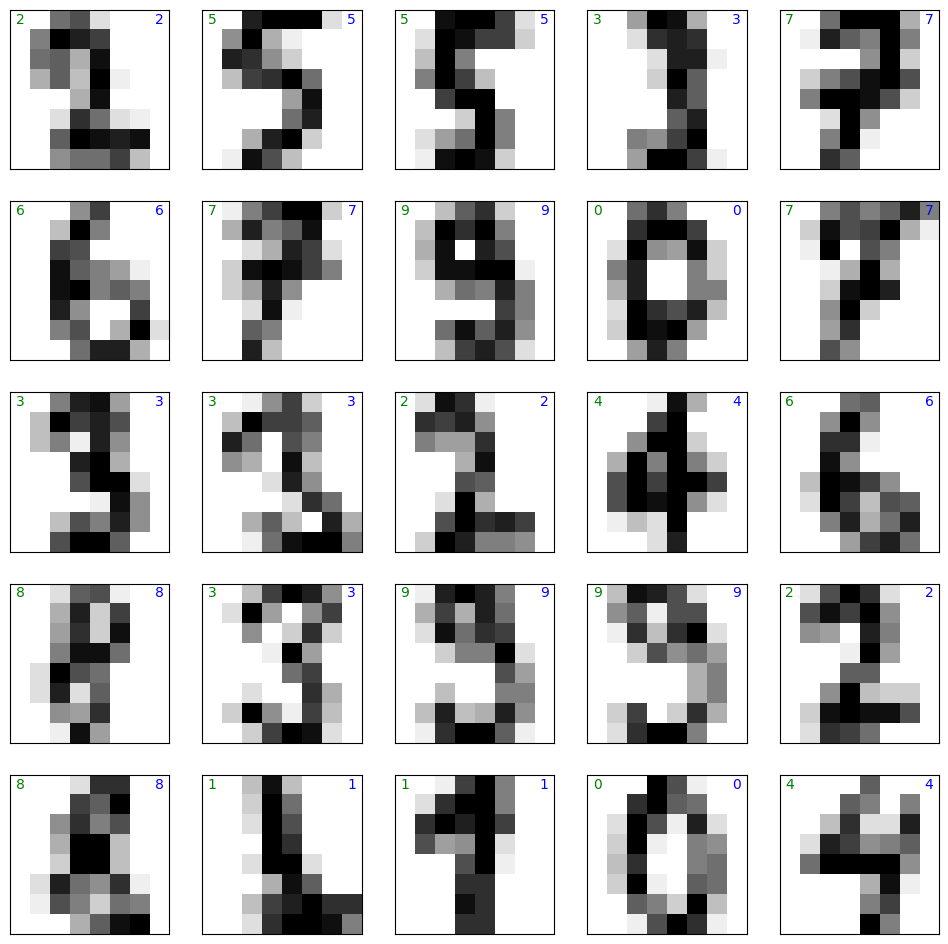

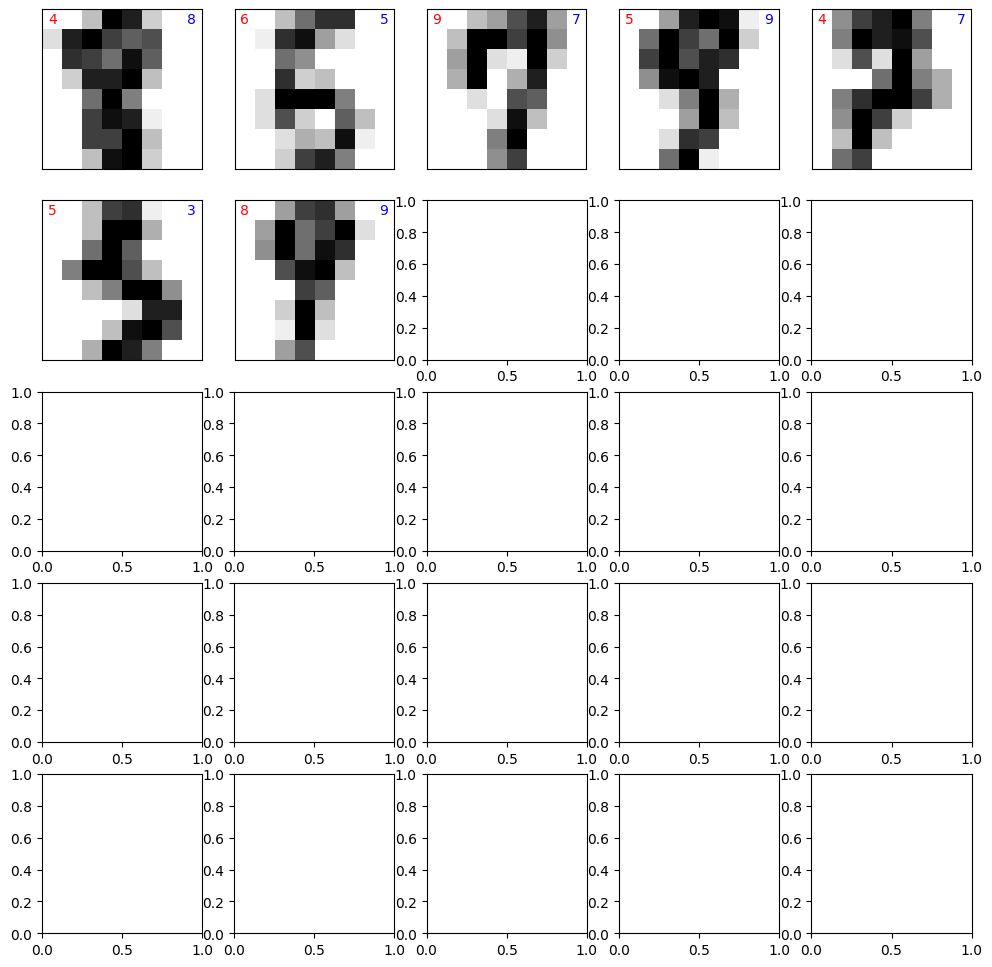

In [17]:
# Ejercicio 5: Visualización de resultados correctos e incorrectos

print("Mejor modelo utilizado:", best_model_name)

# Predicciones correctas
mostrar_resultados(
    digits=digits,
    model=classification_models[best_model_name],
    nx=5,
    ny=5,
    label="correctos"
)

# Predicciones incorrectas
mostrar_resultados(
    digits=digits,
    model=classification_models[best_model_name],
    nx=5,
    ny=5,
    label="incorrectos"
)

La visualización de resultados correctos permite observar ejemplos donde el modelo SVM RBF logró clasificar adecuadamente los dígitos. En estos casos, las imágenes presentan patrones suficientemente claros para que el modelo identifique correctamente la clase correspondiente.

La visualización de errores muestra aquellos casos en que el modelo se equivocó. Estos errores suelen aparecer en imágenes donde los trazos son menos definidos o donde el dígito se parece visualmente a otro. Por ejemplo, algunos números pueden tener formas ambiguas debido a la baja resolución de 8x8 pixeles o a diferencias en la escritura.

Esta revisión visual es importante porque permite entender que los errores del modelo no necesariamente se deben a un mal funcionamiento, sino a la dificultad natural de clasificar imágenes con trazos similares o poco claros.

En general, la baja cantidad de errores visualizados es consistente con el alto desempeño del modelo, que alcanzó cerca de **97,5% de accuracy**.

**Pregunta**

* Tomando en cuenta el mejor modelo entontrado en el `Ejercicio 3`, grafique los resultados cuando:
 * el valor predicho y original son iguales
 * el valor predicho y original son distintos


* Cuando el valor predicho y original son distintos ,  ¿Por qué ocurren estas fallas?

Mejor modelo utilizado: SVM RBF
Cantidad de predicciones correctas: 357
Cantidad de predicciones incorrectas: 3


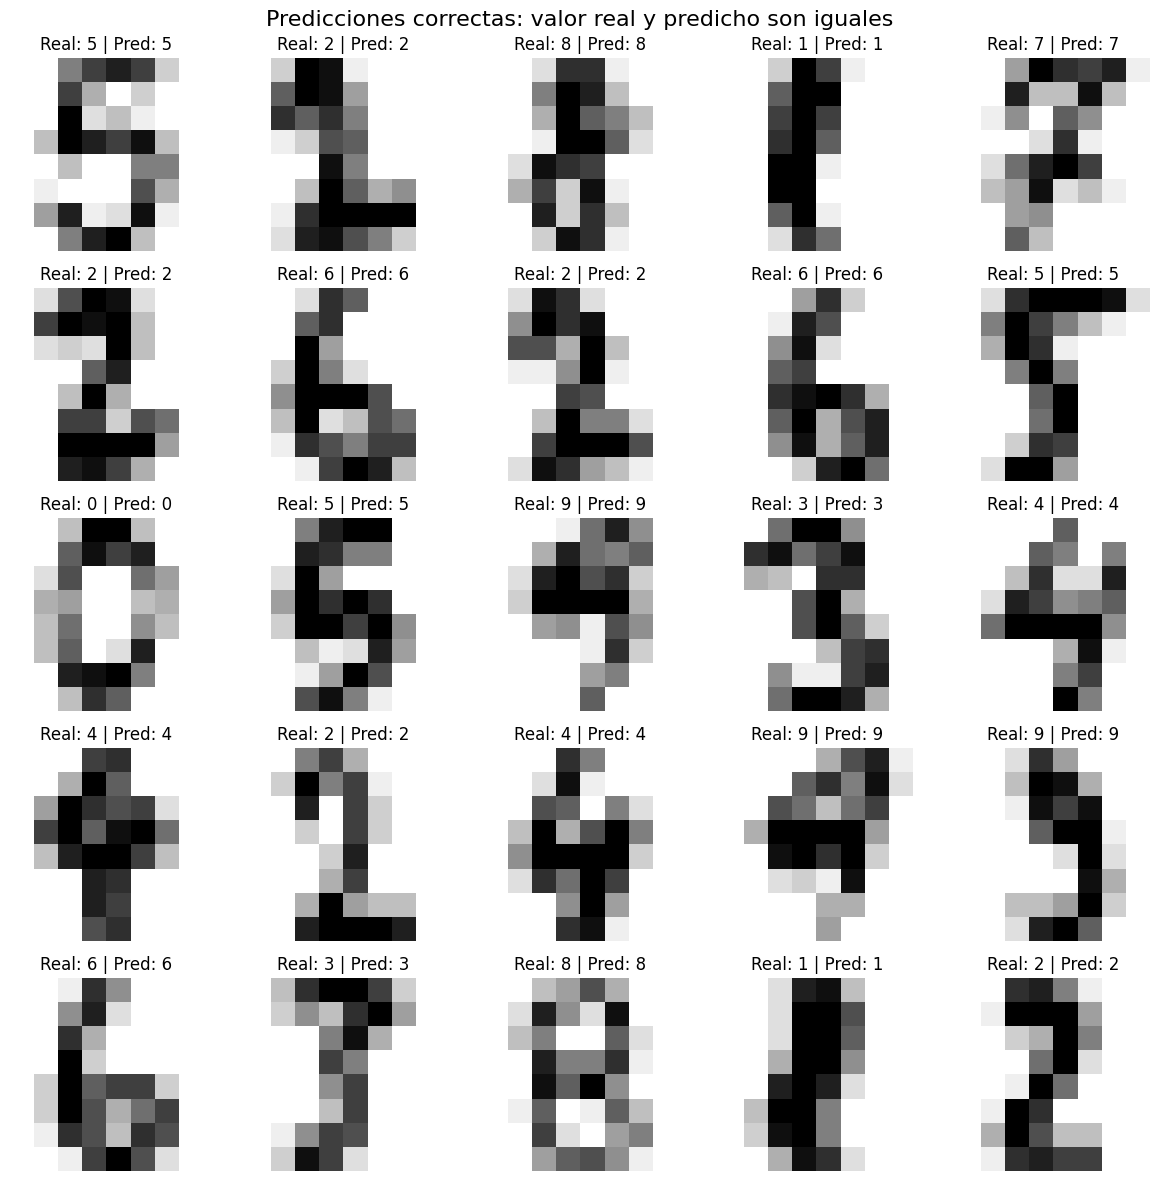

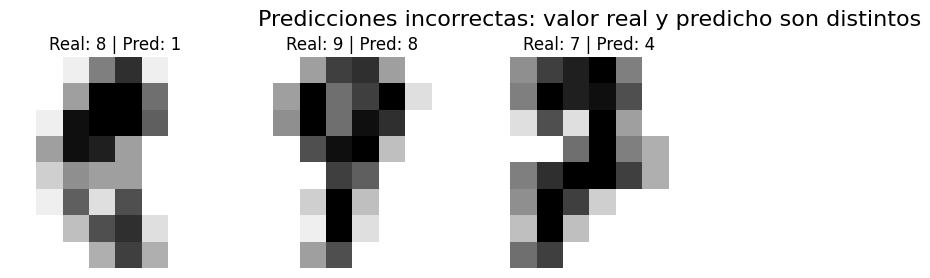

In [18]:
# Usar el mejor modelo encontrado en el Ejercicio 3
print("Mejor modelo utilizado:", best_model_name)

# Obtener predicciones del mejor modelo
y_pred_best = best_model.predict(X_test)

# Crear índices de aciertos y errores
correctos = np.where(y_pred_best == y_test)[0]
incorrectos = np.where(y_pred_best != y_test)[0]

print("Cantidad de predicciones correctas:", len(correctos))
print("Cantidad de predicciones incorrectas:", len(incorrectos))

# Función para graficar imágenes del conjunto de test
def graficar_predicciones(indices, titulo, n=25):
    n = min(n, len(indices))

    if n == 0:
        print(f"No hay casos para mostrar en: {titulo}")
        return

    filas = 5
    columnas = 5

    plt.figure(figsize=(12, 12))

    for i, idx in enumerate(indices[:n]):
        plt.subplot(filas, columnas, i + 1)
        imagen = X_test[idx].reshape(8, 8)
        plt.imshow(imagen, cmap="gray_r")
        plt.title(f"Real: {y_test[idx]} | Pred: {y_pred_best[idx]}")
        plt.axis("off")

    plt.suptitle(titulo, fontsize=16)
    plt.tight_layout()
    plt.show()

# Graficar cuando el valor predicho y original son iguales
graficar_predicciones(
    correctos,
    "Predicciones correctas: valor real y predicho son iguales"
)

# Graficar cuando el valor predicho y original son distintos
graficar_predicciones(
    incorrectos,
    "Predicciones incorrectas: valor real y predicho son distintos"
)

Tomando en cuenta el mejor modelo encontrado en el Ejercicio 3, se utilizó el modelo **SVM RBF** para comparar los valores reales con los valores predichos. El modelo obtuvo **357 predicciones correctas** y solo **3 predicciones incorrectas** sobre el conjunto de prueba. Esto confirma que el desempeño del modelo fue muy alto.

En el primer gráfico, donde el valor predicho y el valor original son iguales, se observa que el modelo logra reconocer correctamente la mayoría de los dígitos. En estos casos, las imágenes tienen trazos relativamente claros y el patrón visual del número coincide con lo aprendido por el modelo durante el entrenamiento. Por ejemplo, se observan casos correctamente clasificados como 5, 2, 8, 1, 7, 6, 0, 9, 3 y 4.

En el segundo gráfico, donde el valor predicho y el valor original son distintos, aparecen los pocos errores del modelo. Los errores observados fueron:

- Un dígito real **8** fue predicho como **1**.
- Un dígito real **9** fue predicho como **8**.
- Un dígito real **7** fue predicho como **4**.

Estas fallas pueden explicarse porque las imágenes del dataset tienen baja resolución, ya que cada dígito está representado en una matriz de solo **8x8 pixeles**. Al tener tan pocos pixeles, algunos trazos pueden perder detalle y hacer que ciertos números se parezcan entre sí.

Por ejemplo, el **9** puede confundirse con un **8** si el trazo superior o inferior está muy cerrado. Del mismo modo, un **7** puede parecerse a un **4** si contiene una línea vertical marcada o si el trazo diagonal no es suficientemente claro. En el caso del **8** predicho como **1**, probablemente el modelo interpretó que los trazos laterales eran poco definidos y priorizó la estructura vertical de la imagen.

En conclusión, los errores ocurren principalmente por la similitud visual entre algunos dígitos, la baja resolución de las imágenes y la presencia de trazos ambiguos o poco claros. Aun así, como solo hubo **3 errores de 360 observaciones**, el modelo SVM RBF demuestra un rendimiento muy alto y una buena capacidad para clasificar correctamente los dígitos.

### Ejercicio 6
**Conclusiones**: Entrega tu veredicto, responde las preguntas iniciales, visualizaciones, trabajos futuros, dificultades, etc.

En este laboratorio se aplicaron técnicas de Machine Learning para resolver dos tipos de problemas: regresión y clasificación.

En la primera parte, se trabajó con el dataset California Housing para predecir el valor medio de viviendas. Se compararon distintos modelos de regresión y el mejor resultado lo obtuvo **Random Forest**, con un **R² de 0,8053** y un **RMSE de 0,5051**. Esto muestra que el modelo logra explicar una parte importante de la variabilidad del valor de las viviendas y supera claramente a los modelos lineales, probablemente porque captura relaciones no lineales entre las variables.

En la segunda parte, se trabajó con el dataset Digits para clasificar imágenes de dígitos escritos a mano. El dataset presentó buena calidad, sin valores nulos ni duplicados, y con clases bastante balanceadas. Se compararon cuatro modelos de clasificación y el mejor desempeño lo obtuvo **SVM RBF**, con un **accuracy de 0,9750** y un **F1 macro de 0,9748**.

Además, la curva AUC-ROC multiclase mostró un **AUC macro de 0,9996**, lo que confirma que el modelo tiene una excelente capacidad para distinguir entre las distintas clases de dígitos. Las matrices de confusión y la visualización de aciertos y errores también respaldan este resultado, mostrando que los errores son pocos y se concentran en casos visualmente más ambiguos.

En conclusión, el laboratorio demuestra la importancia de comparar distintos modelos, evaluar métricas adecuadas y complementar los resultados numéricos con visualizaciones. Para regresión, Random Forest fue el modelo más adecuado; para clasificación, SVM RBF mostró el mejor desempeño general.